In [1]:
# Autoload modules
%load_ext autoreload
%autoreload 2

In [31]:
import sys
sys.path.append('..')
from fcc import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters, ProteinFoldingResult
from vqe import VQEC, VQECOpt
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import Sampler, Estimator
# from qiskit_aer.primitives import Estimator, Sampler
from qiskit_aer import AerSimulator
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombEstimatorGradient
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)
    print(mj_interaction.calculate_energy_matrix(main_seq))

    penalty_back = 50
    penalty_redun = 50
    # penalty_olap = 50

    penalty_terms = PenaltyParameters(penalty_back, penalty_redun)

    peptide = Peptide(main_seq)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [26]:
main_seq_4 = "LFLF" # 6MVZ ("LFLF")YYDPETGTWY
protein_folding_problem = build_pf(main_seq_4)
qubit_op = protein_folding_problem.qubit_op()
print(f"Number of qubits: {qubit_op.num_qubits}")
print(f"Number of terms: {len(qubit_op)}")

[[ 0.   -7.28 -7.37 -7.28]
 [ 0.    0.   -7.28 -7.26]
 [ 0.    0.    0.   -7.28]
 [ 0.    0.    0.    0.  ]]
Number of qubits: 9
Number of terms: 107


In [27]:
bead_pairs, olap_constr_ops = protein_folding_problem.olap_constr_ops()
print(f"Number of overlap constraints: {len(olap_constr_ops)}")
print(f"Number of qubits: {olap_constr_ops[0].num_qubits}")

Number of overlap constraints: 1
Number of qubits: 9


In [32]:
ansatz = RealAmplitudes(qubit_op.num_qubits, reps=2)
estimator = Estimator()
# estimator = Estimator(backend_options={'method': 'matrix_product_state'})
gradient = LinCombEstimatorGradient(estimator=estimator)
vqec = VQECOpt(qubit_op=qubit_op, constr_ops=olap_constr_ops, ansatz=ansatz, estimator=estimator, gradient=gradient, max_iter=100)
vqec_result = vqec.optimize_primal_dual()
print(vqec_result.optimal_primal_vars)
print(vqec_result.optimal_dual_vars)

 66%|██████▌   | 66/100 [00:10<00:05,  6.27it/s]

Converged after 67 iterations
[4.27253444e+00 2.03054527e-03 1.03145933e+00 3.14293076e+00
 3.14085794e+00 5.39800771e+00 5.24428115e+00 4.73029470e+00
 4.71240124e+00 3.88494400e+00 2.34798806e+00 1.56686286e+00
 4.71502456e+00 1.57025212e+00 2.38219420e+00 5.92650521e+00
 6.29718155e+00 3.14159200e+00 1.25232101e+00 3.44929763e+00
 4.72403897e+00 5.85594673e+00 1.57213552e+00 1.58300147e+00
 4.30889092e+00 1.59344387e+00 4.71231304e+00]
[0.]


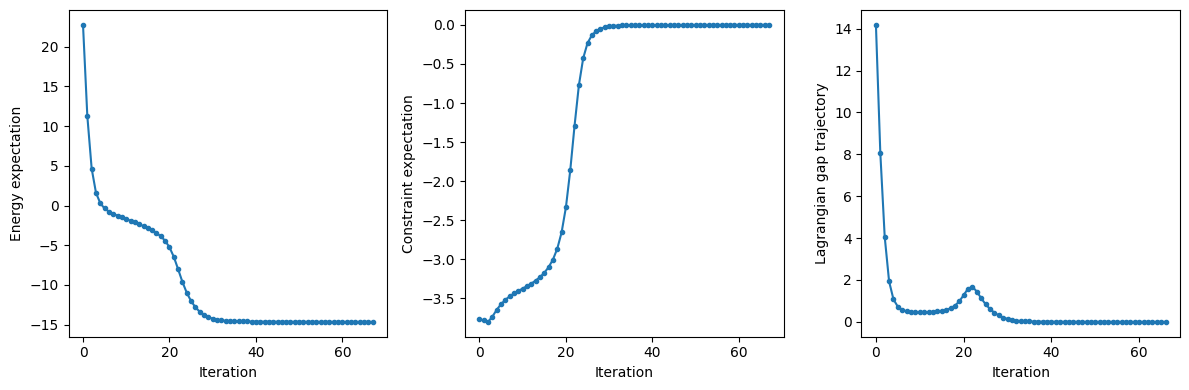

In [33]:
# Plot the results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(vqec_result.energies, label="Energy", marker=".")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Energy expectation")

ax[1].plot(vqec_result.constraints[:, 0], label="Overlap", marker=".")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Constraint expectation")

ax[2].plot(vqec_result.lagrangian_gap_trajectory, label="Dual", marker=".")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Lagrangian gap trajectory")



plt.tight_layout()
plt.show()

In [35]:
full_circ = vqec_result.ansatz.copy()
full_circ.measure_all()
sampler = Sampler(options={"shots": 10000})
# sampler = Sampler(run_options={"shots": 10000})
sampler_result = sampler.run(circuits=[full_circ], parameter_values=vqec_result.optimal_primal_vars).result()
quasi_dist = sampler_result.quasi_dists[0].binary_probabilities()

# Sort the binary strings by their probabilities
sorted_quasi_dist = dict(sorted(quasi_dist.items(), key=lambda item: item[1], reverse=True))
# Compute the energies of all samples
from qufold.execution_utils.measurements import _evaluate_sparsepauli
bitstring_energies = {}
for i, (sample, prob) in enumerate(sorted_quasi_dist.items()):
    if i >= 5:
        break
    energy = _evaluate_sparsepauli(sample, qubit_op)
    bitstring_energies[sample] = energy
    print(f"Sample {i}: {sample} with probability {prob} and energy {energy}")

Sample 0: 011111010 with probability 0.7879 and energy -14.650000000000006
Sample 1: 011110010 with probability 0.212 and energy -14.649999999999997
Sample 2: 011111110 with probability 0.0001 and energy -14.64999999999999


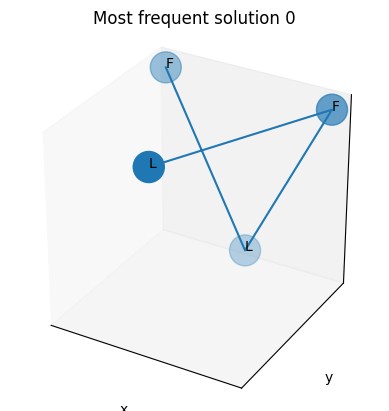

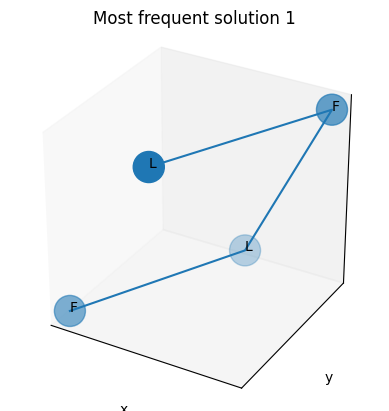

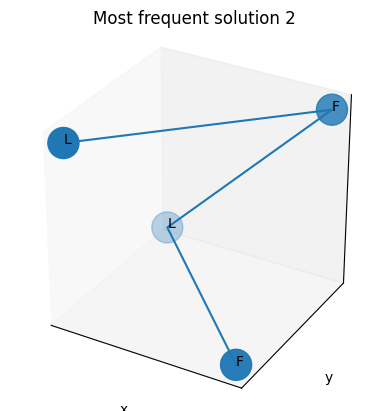

In [36]:
for i, (sample, energy) in enumerate(bitstring_energies.items()):
    pf_result = ProteinFoldingResult(peptide=protein_folding_problem.peptide, unused_qubits=protein_folding_problem.unused_qubits, solution_bitstring=sample)
    fig = pf_result.get_figure(title=f"Most frequent solution {i}")
    plt.show()